# K-Means Phân Cụm Rủi Ro Tín Dụng (Dùng Thư Viện Sklearn)
So sánh kết quả với bản tự cài đặt (KMeansScratch)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import urllib
import warnings
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

warnings.filterwarnings('ignore')

In [2]:
# Kết nối SQL Server
server = 'localhost,1433'
database = 'fintech'
username = 'sa'
password = 'admin'

connection_string = (
    r'DRIVER={ODBC Driver 17 for SQL Server};'
    f'SERVER={server};'
    f'DATABASE={database};'
    f'UID={username};'
    f'PWD={password};'
)
params = urllib.parse.quote_plus(connection_string)
engine = create_engine(f"mssql+pyodbc:///?odbc_connect={params}")
print('Đã thiết lập kết nối tới CSDL!')

Đã thiết lập kết nối tới CSDL!


In [3]:
# Đọc dữ liệu PCA
df_pca_train = pd.read_sql('SELECT * FROM pca_credit_risk_train', engine)

if 'loan_status' in df_pca_train.columns:
    X_pca = df_pca_train.drop('loan_status', axis=1).values
else:
    X_pca = df_pca_train.values

print('Kích thước dữ liệu PCA train:', X_pca.shape)

Kích thước dữ liệu PCA train: (40746, 13)


## 1. Tìm K tối ưu bằng Elbow Method + Silhouette Score
Đây là bước mà bản KMeansScratch **không làm được** — ưu điểm của thư viện sklearn.

In [4]:
# Thử K từ 2 đến 8, tính Inertia và Silhouette
k_range = range(2, 9)
inertias = []
silhouettes = []

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    km.fit(X_pca)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_pca, km.labels_, sample_size=5000, random_state=42)
    silhouettes.append(sil)
    print(f'K={k} | Inertia: {km.inertia_:,.0f} | Silhouette: {sil:.4f}')

K=2 | Inertia: 200,408 | Silhouette: 0.2687
K=3 | Inertia: 158,423 | Silhouette: 0.2474
K=4 | Inertia: 138,311 | Silhouette: 0.2442
K=5 | Inertia: 126,679 | Silhouette: 0.2284
K=6 | Inertia: 117,493 | Silhouette: 0.1876
K=7 | Inertia: 111,033 | Silhouette: 0.1668
K=8 | Inertia: 105,783 | Silhouette: 0.1687


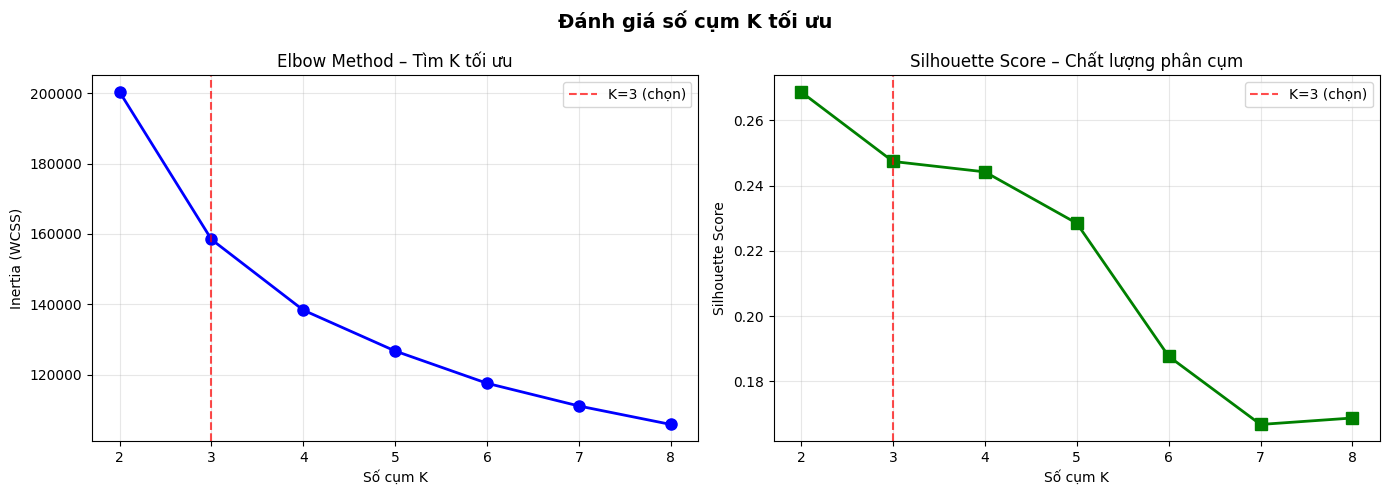

In [5]:
# Vẽ Elbow + Silhouette
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Elbow Method
ax1.plot(list(k_range), inertias, 'bo-', linewidth=2, markersize=8)
ax1.axvline(x=3, color='red', linestyle='--', alpha=0.7, label='K=3 (chọn)')
ax1.set_xlabel('Số cụm K')
ax1.set_ylabel('Inertia (WCSS)')
ax1.set_title('Elbow Method – Tìm K tối ưu')
ax1.legend()
ax1.grid(alpha=0.3)

# Silhouette Score
ax2.plot(list(k_range), silhouettes, 'gs-', linewidth=2, markersize=8)
ax2.axvline(x=3, color='red', linestyle='--', alpha=0.7, label='K=3 (chọn)')
ax2.set_xlabel('Số cụm K')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score – Chất lượng phân cụm')
ax2.legend()
ax2.grid(alpha=0.3)

plt.suptitle('Đánh giá số cụm K tối ưu', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 2. Chạy KMeans Sklearn với K=3

In [6]:
# KMeans sklearn - init='k-means++' là mặc định, tương đương bản tự cài
kmeans_sk = KMeans(
    n_clusters=3,
    init='k-means++',   # khởi tạo thông minh, giống KMeans++ tự cài
    n_init=10,          # chạy 10 lần với seed khác nhau, chọn kết quả tốt nhất
    max_iter=300,
    random_state=42
)

kmeans_sk.fit(X_pca)
df_pca_train['Risk_Cluster_SK'] = kmeans_sk.labels_

print('Số vòng lặp hội tụ:', kmeans_sk.n_iter_)
print('Inertia:', f'{kmeans_sk.inertia_:,.2f}')
print('Silhouette Score:', f'{silhouette_score(X_pca, kmeans_sk.labels_, sample_size=5000, random_state=42):.4f}')
print('\nPhân bố các cụm:\n', df_pca_train['Risk_Cluster_SK'].value_counts())

Số vòng lặp hội tụ: 55
Inertia: 158,423.19
Silhouette Score: 0.2474

Phân bố các cụm:
 Risk_Cluster_SK
0    20090
1    11443
2     9213
Name: count, dtype: int64


## 3. Trực quan hóa kết quả

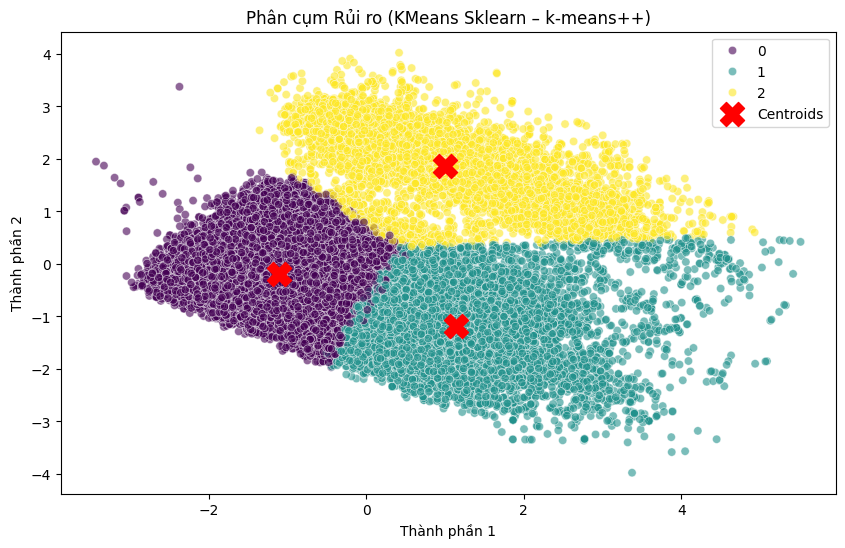

In [7]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=X_pca[:, 0], y=X_pca[:, 1],
    hue=df_pca_train['Risk_Cluster_SK'],
    palette='viridis', alpha=0.6
)
plt.scatter(
    kmeans_sk.cluster_centers_[:, 0],
    kmeans_sk.cluster_centers_[:, 1],
    s=300, c='red', marker='X', label='Centroids'
)
plt.title('Phân cụm Rủi ro (KMeans Sklearn – k-means++)')
plt.xlabel('Thành phần 1')
plt.ylabel('Thành phần 2')
plt.legend()
plt.show()

## 4. Phân tích đặc điểm từng cụm

In [10]:
cluster_summary = df_pca_train.groupby('Risk_Cluster_SK').mean(numeric_only=True)
print('Trung bình các cụm:')
print(cluster_summary)

# Xác định nhãn rủi ro dựa trên loan_status trung bình
print('\n=== Tỷ lệ vỡ nợ theo cụm ===')
# Sắp xếp theo loan_status mean từ thấp đến cao
risk_order = cluster_summary['loan_status'].sort_values()

labels = ['Rủi ro THẤP', 'Rủi ro TRUNG BÌNH', 'Rủi ro CAO']
risk_map = {}
for i, cluster_id in enumerate(risk_order.index):
    risk_map[cluster_id] = labels[i]
    print(f"Cluster {cluster_id}: mean={risk_order[cluster_id]:.3f} → {labels[i]}")

print("\nMapping:", risk_map)

Trung bình các cụm:
                      PC1       PC2       PC3  person_home_ownership_MORTGAGE  \
Risk_Cluster_SK                                                                 
0               -1.107444 -0.184452  0.033771                        0.416625   
1                1.143515 -1.178423 -0.019641                        0.248099   
2                0.994607  1.865879 -0.049246                        0.306415   

                 person_home_ownership_OTHER  person_home_ownership_OWN  \
Risk_Cluster_SK                                                           
0                                   0.002140                   0.067845   
1                                   0.003146                   0.056017   
2                                   0.005644                   0.046022   

                 person_home_ownership_RENT  loan_intent_DEBTCONSOLIDATION  \
Risk_Cluster_SK                                                              
0                                  0.51339

In [11]:
print("=== Tỷ lệ vỡ nợ theo cụm ===")
print(cluster_summary['loan_status'].sort_values())

=== Tỷ lệ vỡ nợ theo cụm ===
Risk_Cluster_SK
0    0.310801
2    0.679040
1    0.688019
Name: loan_status, dtype: float64


## 5. So sánh Sklearn vs Scratch

In [12]:
print('=== SO SÁNH SKLEARN vs SCRATCH ===')
print(f'{'':25} {'Sklearn':>15} {'Scratch':>15}')
print('-' * 55)
print(f'{'Initialization':25} {'k-means++':>15} {'Random':>15}')
print(f'{'n_init (số lần chạy)':25} {'10':>15} {'1':>15}')
print(f'{'Inertia':25} {kmeans_sk.inertia_:>15,.2f} {'N/A':>15}')
print(f'{'Silhouette Score':25} {silhouette_score(X_pca, kmeans_sk.labels_, sample_size=5000, random_state=42):>15.4f} {'N/A':>15}')
print(f'{'Hội tụ (vòng lặp)':25} {kmeans_sk.n_iter_:>15} {'16':>15}')

=== SO SÁNH SKLEARN vs SCRATCH ===
                                  Sklearn         Scratch
-------------------------------------------------------
Initialization                  k-means++          Random
n_init (số lần chạy)                   10               1
Inertia                        158,423.19             N/A
Silhouette Score                   0.2474             N/A
Hội tụ (vòng lặp)                      55              16
